### Imports and Setup

In [15]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
import pyproj as proj
import h5py
import itertools

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import L2Standardize, MultilaterationOpt, WAVReader, ClipAnalyzer, ParLocalizer
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.transformations import to_spect, get_image_transform_range_classify

Some Setup For Global Variables

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0]) # np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
TOSSIT_locations = np.asarray([-ys, xs]).T

# get image transforms
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))

# root path to experimental data examples
ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

# load model and weights
model = TCNRangeAndClassify(input_size=232,
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.1).to(device)
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

Using the GPU!


Load Experimental Example

In [39]:
idx = [44, 53]
# idx = [44]
# idx = [53]

# load
with h5py.File(os.path.join("/",ccb_data_root,"gunshots" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
    inputs_short = f["/data"][:]
    sensors_short = f["/sensors"][:].squeeze()
    true_latlon_short = f["/location"][:].T
    associations_short = f["/associations"][:].squeeze()

try:
    with h5py.File(os.path.join("/",ccb_data_root,"gunshots_long" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
        inputs_long = f["/data"][:]
        sensors_long = f["/sensors"][:].squeeze()
        true_latlon_long = f["/location"][:].T
    assert (i == j for i, j in zip(true_latlon_short, true_latlon_long)), "True locations are different"
except:
    raise FileNotFoundError("Corresponding long file is not available")

### Helper Functions

In [40]:
def circle(r, a, b):
    """
    Produce points on a circle.
    
    Parameters
    ----------
    r : float
        radius of circle
    a : float
        x coordinate of circle center
    b : float
        y coordinate of circle center
        
    Returns
    -------
    (x, y) : Tuple[array-like, array-like]
        lists of x and y points on the circle perimeter
    """
    
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

def localize(r_p, sensors_idx, TOSSIT_locations):
    """
    Use iterative optimization method to localize a source.
    
    Parameters
    ----------
    r_p : np.ndarray
        predicted ranges
    sensors_idx : np.ndarray
        sensors corresponding to r_p values
    TOSSIT_locations : np.ndarray
        locations of sensors of shape N X 2
        
    Returns
    -------
    loc : np.ndarray
        array of location estimate
    """
    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc

def sensor2idx(sensors):
    """
    Convert TOSSIT ID numbers to index in
    the list defined at config['TOSSIT']['ids'].
    
    Parameters
    ----------
    sensors : List[float] or List[int]
        list of sensor IDs
    
    Returns
    -------
    List[Int]
        list of sensor indices
    """
        
    return [config['TOSSIT']['ids'].index(str(int(s))) for s in sensors]

def preprocess_individual_examples(inputs, true_latlon):
    """
    Preprocess individual examples for processing.
    
    Parameters
    ----------
    inputs : np.ndarrray
        input time-domain signals of shape, (N X samples/signal)
    true_latlon : np.ndarray
        true locations associated with the range measurements
    
    Returns
    -------
    inputs : torch.Tensor
        preprocessed spectrograms
    ranges : np.ndarray
        corresponding true ranges
    location_m : np.ndarray
        true source locations
    """

    if len(true_latlon.shape) == 1:
        true_latlon = true_latlon[np.newaxis,:]
    
    # get position and sensor ranges
    location_m = np.zeros(true_latlon.shape)
    ranges = []
    for idx, tll in enumerate(true_latlon):
        xt, yt = pargs(tll[1], tll[0])
        yt = -yt
        location_m[idx,:] = np.asarray([[yt, xt]])
        ranges.extend(np.sqrt(((TOSSIT_locations - location_m[idx,:]) ** 2).sum(axis=1)))
    
    # preprocess
    inputs = preprocessor(inputs)

    return inputs, np.asarray(ranges), location_m

def scan_data(CA, inputs, true_latlon):
    """
    Scans long audio segments from all sensors using model.
    
    Parameters
    ----------
    CA : Clipanalyzer object
        object used to scan audio
    inputs : np.ndarrray
        input time-domain signals of shape, (N X samples/signal)
    true_latlon : np.ndarray
        true locations in lat/lon
        
    Returns
    -------
    rp : List[np.ndarray]
        resulting range predictions on each sensor
    spects : np.ndarray
        preprocessed spectrograms that were detected
    location_m : np.ndarray
        true locations in meters
    """
    
    if len(true_latlon.shape) == 1:
        true_latlon = true_latlon[np.newaxis,:]
    
    # get position and sensor ranges
    location_m = np.zeros(true_latlon.shape)
    for idx, tll in enumerate(true_latlon):
        xt, yt = pargs(tll[1], tll[0])
        yt = -yt
        location_m[idx,:] = np.asarray([[yt, xt]])

    result = CA.process_clips(inputs)

    rp = [x[1] for x in result]
    spects = [x[0] for x in result]
    
    return rp, spects, location_m
    
def plot_range_regression(r_t, r_p):
    """
    Plot true and predicted ranges.
    
    Parameters
    ----------
    r_t : array-like
        true ranges
    r_p : array-like
        predicted ranges
    """
    # get endpoints for identity line
    r_mm = (0, config['scaling']['max_r'] + 5000)
    
    plt.plot(r_t / 1000, r_p / 1000, 'bo', markersize=4)
    plt.plot([r_mm[0] / 1000, r_mm[1] / 1000], [r_mm[0] / 1000, r_mm[1] / 1000], 'r--', label="identity line")
    plt.grid()
    plt.xlabel("True Range [km]")
    plt.ylabel("Predicted Range [km]")
    plt.legend()
    plt.xlim(0, 20)
    plt.ylim(0, 20)
    
def plot_localization(rp, true_loc, sensors, est_loc=None, circles=False):
    """
    Plot true and estimated locations in the context of the TOSSIT sensors.
    
    Parameters
    ----------
    rp : np.ndarray
        ranges
    true_loc :  
    """
    
    if (not isinstance(rp[0], np.ndarray)) and (not isinstance(rp[0], list)):
        rp = [rp]
        
    if (not isinstance(sensors[0], np.ndarray)) and (not isinstance(sensors[0], list)):
        sensors = [sensors]
        
    color_list = ["blue", "red", "green", "purple", "orange", "black"]
    
    # plot TOSSITs
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], 'kx', markersize=10, label="TOSSIT")

    # plot predicted location with range circles
    if est_loc is not None:
        for idx_assoc, (assoc_rp, assoc_sensors) in enumerate(zip(rp, sensors)):
            for idx, (r, s) in enumerate(zip(assoc_rp, assoc_sensors)):
                if circles:
                    x, y = circle(r, TOSSIT_locations[s,1], TOSSIT_locations[s,0])
                    plt.plot(x, y, '-', c=color_list[idx_assoc])
        
        if len(est_loc.shape) == 1:
            est_loc = est_loc[np.newaxis, :]
        for idx, el in enumerate(est_loc):
            plt.plot(el[1], el[0], 'ro', label="Location Estimate" if idx == 0 else None, markersize=10)
    
    # plot true location
    if len(true_loc.shape) == 1:
        true_loc = true_loc[np.newaxis, :]
    for idx, tl in enumerate(true_loc):
        plt.plot(tl[1], tl[0], 'g^', label="True Location" if idx == 0 else None, markersize=10)

    # labels
    plt.gca().invert_yaxis()
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.legend()

### Manual Localization

Preprocess Data

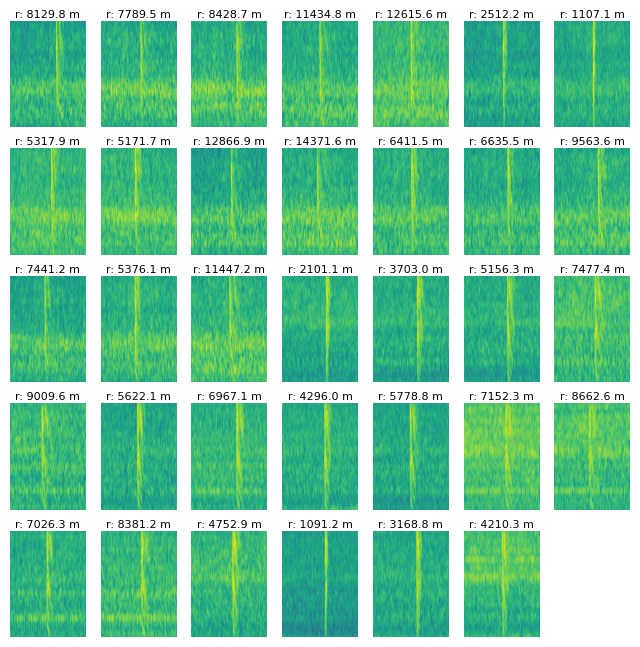

In [41]:
# preprocess the individual examples
inputs_short, ranges_short, true_location_m_short = preprocess_individual_examples(inputs_short,
                                                                                   true_latlon_short)
# display data
rows = int(np.floor(np.sqrt(inputs_short.shape[0])));
columns = int(np.ceil(inputs_short.shape[0]/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= inputs_short.shape[0]:
            fig.delaxes(ax2)
        else:
            ax2.imshow(inputs_short[c,...], aspect='auto')
            ax2.axis('off')
            ax2.set_title(f"r: {np.around(ranges_short[c], 1)} m",fontsize=8, y=0.95)
        c += 1

Run The Network And Get Ranges

statistics
-------------------
MAE: 869.875 m
MAE All: 1656.162 m


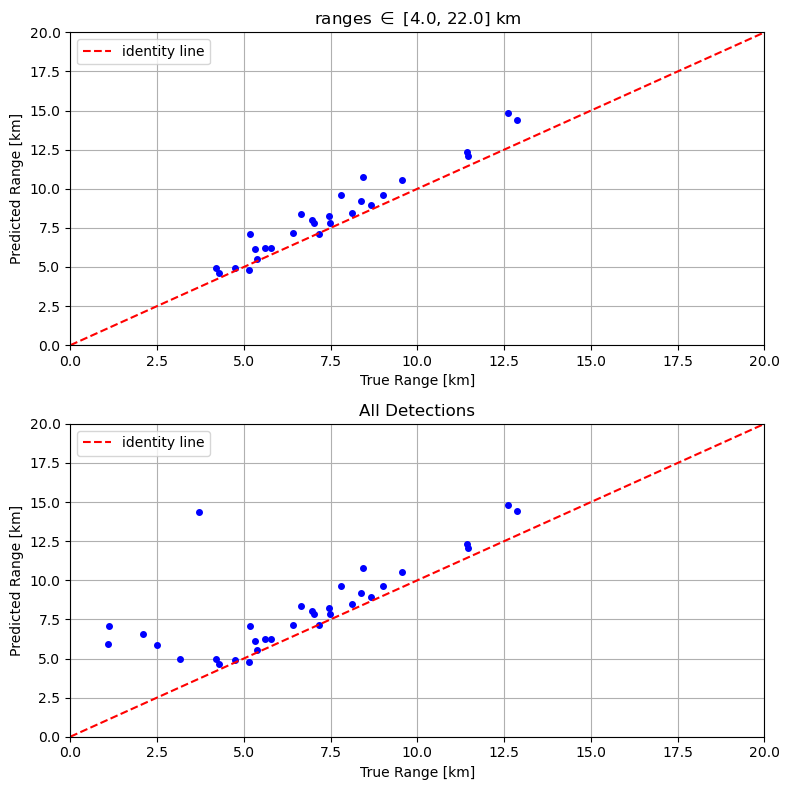

In [42]:
with torch.set_grad_enabled(False):
    inputs_short = inputs_short.to(device)
    outputs_short = model(inputs_short).to('cpu')

############################################
#   Calls With r <= r_max And r >= r_min
############################################
# get indices of detections and where 
# true ranges fall in synthetic range distribution
detections_idx = np.where((F.softmax(outputs_short[:,1:], dim=1)[:,1] >= 0.5) & (ranges_short >= config['scaling']['min_r']) & (ranges_short <= config['scaling']['max_r']))[0]

# get predicted ranges and their corresponding sensor indices and source associations
rp_short = (outputs_short[detections_idx,0] * config['scaling']['max_r']).numpy()
sensors_idx_short = np.asarray(sensor2idx(sensors_short[detections_idx]))
associationsp_short = associations_short[detections_idx]

##################################
#           All Ranges
##################################
# get indices of detections and where 
# true ranges fall in synthetic range distribution
detections_idx_all = np.where((F.softmax(outputs_short[:,1:], dim=1)[:,1] >= 0.5))[0]

# get predicted ranges and their corresponding sensor indices and source associations
rp_short_all = (outputs_short[detections_idx_all,0] * config['scaling']['max_r']).numpy()
sensors_idx_short_all = np.asarray(sensor2idx(sensors_short[detections_idx_all]))
associationsp_short_all = associations_short[detections_idx_all]

plt.subplot(2,1,1)
plt.title(f"ranges $\in$ [{config['scaling']['min_r'] / 1000}, {config['scaling']['max_r'] / 1000}] km")
plot_range_regression(ranges_short[detections_idx], rp_short)
plt.subplot(2,1,2)
plt.title("All Detections")
plot_range_regression(ranges_short[detections_idx_all], rp_short_all)
plt.tight_layout()
print("statistics")
print("-------------------")
print(f'MAE: {np.around(np.abs(rp_short - ranges_short[detections_idx]).mean(), 3)} m')
print(f'MAE All: {np.around(np.abs(rp_short_all - ranges_short[detections_idx_all]).mean(), 3)} m')

Manually Localize

In [43]:
loc_short = np.zeros(true_latlon_short.shape)
loc_short_all = np.zeros(true_latlon_short.shape)

range_assoc_short = []
range_assoc_short_all = []
sensors_assoc_short = []
sensors_assoc_short_all = []
for idx, assoc in enumerate(range(len(np.unique(associations_short)))):
    # get ranges
    rp_assoc_short = rp_short[associationsp_short == assoc]
    rp_assoc_short_all = rp_short_all[associationsp_short_all == assoc]
    s = sensors_idx_short[associationsp_short == assoc]
    ss = sensors_idx_short_all[associationsp_short_all == assoc]
    
    range_assoc_short.append(rp_assoc_short)
    range_assoc_short_all.append(rp_assoc_short_all)
    sensors_assoc_short.append(s)
    sensors_assoc_short_all.append(ss)
    
    # localize
    loc_short[idx,:] = localize(rp_assoc_short, s, TOSSIT_locations)
    loc_short_all[idx,:] = localize(rp_assoc_short_all, ss, TOSSIT_locations)

statistics
-------------------
Error: [1371.846, 835.2] m
Error All: [1923.824, 2733.332] m


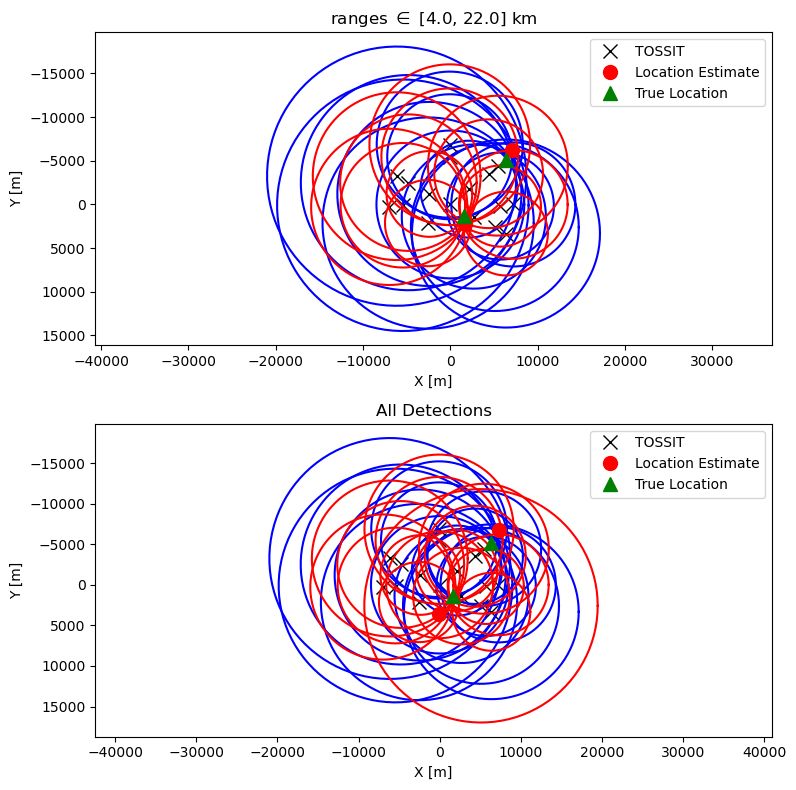

In [44]:
plt.subplot(2,1,1)
plot_localization(range_assoc_short, true_location_m_short, sensors_assoc_short, loc_short, circles=True)
plt.title(f"ranges $\in$ [{config['scaling']['min_r'] / 1000}, {config['scaling']['max_r'] / 1000}] km")
plt.axis('equal')
plt.subplot(2,1,2)
plot_localization(range_assoc_short_all, true_location_m_short, sensors_assoc_short_all, loc_short_all, circles=True)
plt.title("All Detections")
plt.axis('equal')
plt.tight_layout()

print("statistics")
print("-------------------")
print(f'Error: {[np.around(np.sqrt(((loc_short[i,:] - true_location_m_short[i,:]) ** 2).sum()), 3) for i in range(true_location_m_short.shape[0])]} m')
print(f'Error All: {[np.around(np.sqrt(((loc_short_all[i,:] - true_location_m_short[i,:]) ** 2).sum()), 3) for i in range(true_location_m_short.shape[0])]} m')

### Scan and Localize

Get Data Scanner

In [45]:
data_params = {'fs' : config['signal']['fs'],
               'T' : config['signal']['T'],}
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))
CA = ClipAnalyzer(model, 
                  data_params, 
                  preprocessor,
                  device)

Scan Data For Calls

Text(0.5, 0.98, 'Detected Calls')

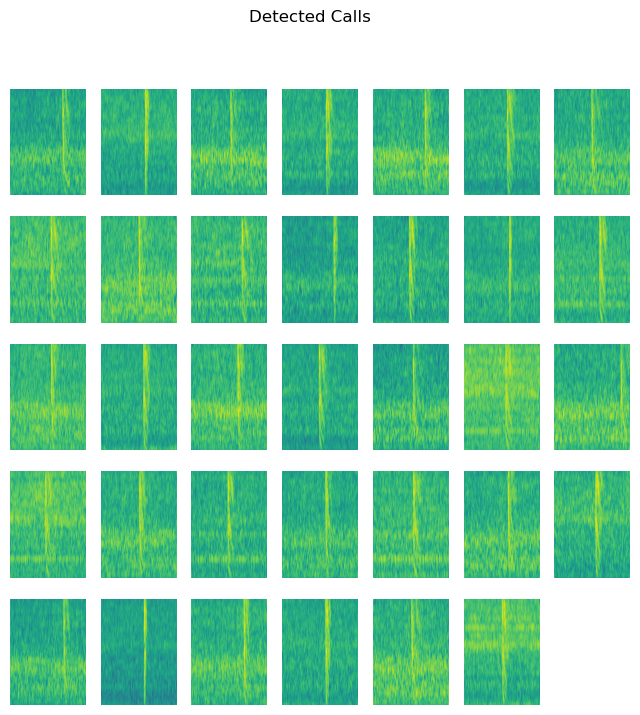

In [46]:
# scan long data intervals which contain the 
rp_long, spects_long, true_location_m_long = scan_data(CA, inputs_long, true_latlon_long)

# get linear arrays of all detected ranges, corresponding sensors, and corresponding spectrograms
rp_linear = []
sensor_list = []
detected_spects = []
for idx,(r,s) in enumerate(zip(rp_long, spects_long)):
    for rr, ss in zip(r, s):
        rp_linear.append(rr)
        sensor_list.append(idx)
        detected_spects.append(ss)

# plot detected spectrograms
rows = int(np.floor(np.sqrt(len(detected_spects))));
columns = int(np.ceil(len(detected_spects)/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= len(detected_spects):
            fig.delaxes(ax2)
        else:
            ax2.imshow(detected_spects[c].squeeze(), aspect='auto')
            ax2.axis('off')
        c += 1
fig.suptitle("Detected Calls")

Associate And Localize

In [47]:
L = ParLocalizer(k=6, multilat=MultilaterationOpt(method_thresh=float('inf')), consistency_thresh=800, TOSSIT_locations=TOSSIT_locations, min_assoc_size=9)

In [48]:
success = L.set_measurements(rp_long)

assocs, loc = L.associate_and_localize(reduce_dups=False, last_step=True)

assert (loc.shape[0] == true_location_m_long.shape[0]), "Number of predicted and actual locations do not match"

statistics
-------------------
Error Manual: [1371.846, 835.2] m
Error Automatic: [1169.769, 989.721] m


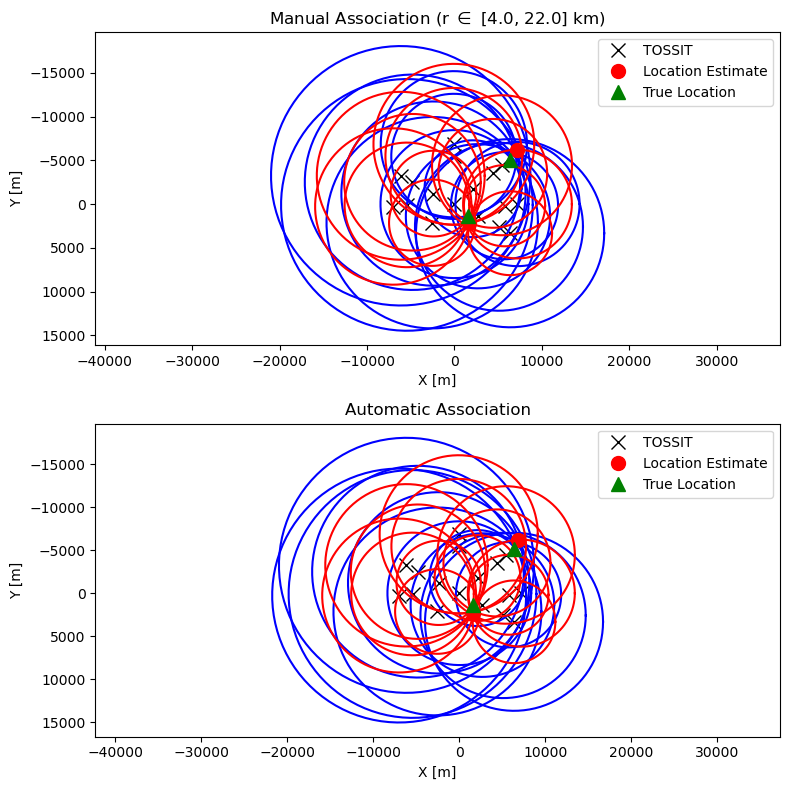

In [49]:
range_assoc_long = []
sensors_assoc_long = []

spects_final = []
for assoc in assocs:
    range_assoc_long.extend([[rp_linear[idx] for idx in assoc]])
    sensors_assoc_long.extend([[sensor_list[idx] for idx in assoc]])
    spects_final.extend([detected_spects[idx] for idx in assoc])

plt.subplot(2,1,1)
plot_localization(range_assoc_short, true_location_m_short, sensors_assoc_short, loc_short, circles=True)
plt.title(f"Manual Association (r $\in$ [{config['scaling']['min_r'] / 1000}, {config['scaling']['max_r'] / 1000}] km)")
plt.axis('equal')
plt.subplot(2,1,2)
plot_localization(range_assoc_long, true_location_m_long, sensors_assoc_long, loc, circles=True)
plt.title("Automatic Association")
plt.axis('equal')
plt.tight_layout()

# ensure label/predicted locations are aligned
num_ests = loc.shape[0]
source_loc_combs = np.asarray(list(map(list, itertools.permutations(true_location_m_long))))
errors_matrix = np.sqrt(((source_loc_combs[:,:num_ests,:] - loc[np.newaxis,:,:]) ** 2).sum(axis=2)).sum(axis=1)
ordered_source_locs = source_loc_combs[np.argmin(errors_matrix)]

print("statistics")
print("-------------------")
print(f'Error Manual: {[np.around(np.sqrt(((loc_short[i,:] - true_location_m_short[i,:]) ** 2).sum()), 3) for i in range(true_location_m_short.shape[0])]} m')
print(f'Error Automatic: {[np.around(np.sqrt(((loc[j,:] - ordered_source_locs[i,:]) ** 2).sum()), 3) for i, j in zip(range(true_location_m_long.shape[0]), range(true_location_m_long.shape[0]))]} m')

Text(0.5, 0.98, 'Utilized Calls')

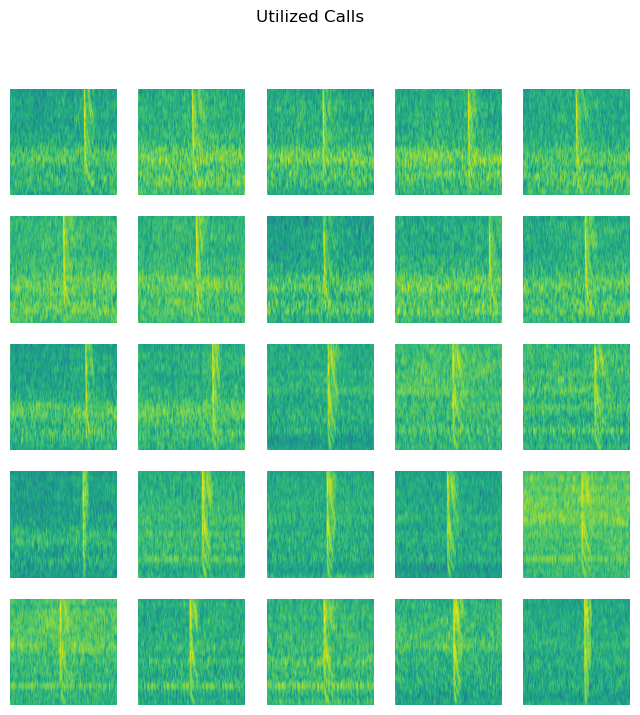

In [14]:
rows = int(np.floor(np.sqrt(len(spects_final))));
columns = int(np.ceil(len(spects_final)/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= len(spects_final):
            fig.delaxes(ax2)
        else:
            ax2.imshow(spects_final[c].squeeze(), aspect='auto')
            ax2.axis('off')
        c += 1
fig.suptitle("Utilized Calls")